<a href="https://colab.research.google.com/github/Raghulazhagiah/PRML_Lab_3/blob/main/PRML_Assignment_4_submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from numpy.linalg import eig, inv, det
from scipy.stats import multivariate_normal

In [2]:
# Isotropic covariance

np.random.seed(42)
N = 1000
mu1 = 2
mu2 = 5
sigma = 1

D1 = np.random.normal(mu1, sigma, N)
D2 = np.random.normal(mu2, sigma, N)
X = np.column_stack((D1, D2))

print("First 5 data points:")
print(X[:10])

First 5 data points:
[[2.49671415 6.39935544]
 [1.8617357  5.92463368]
 [2.64768854 5.05963037]
 [3.52302986 4.35306322]
 [1.76584663 5.69822331]
 [1.76586304 5.39348539]
 [3.57921282 5.89519322]
 [2.76743473 5.6351718 ]
 [1.53052561 6.04955272]
 [2.54256004 4.46476479]]


In [3]:
def estimate_covariance(X):

    mean = np.mean(X, axis=0)

    covariance = np.cov(X, rowvar=False)

    eigenvalues, eigenvectors = eig(covariance)

    eigenvalues = np.real(eigenvalues)
    eigenvectors = np.real(eigenvectors)

    idx = np.argsort(eigenvalues)[::-1]

    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    return mean, covariance, eigenvalues, eigenvectors

In [4]:
mean, covariance, eigenvalues, eigenvectors = estimate_covariance(X)

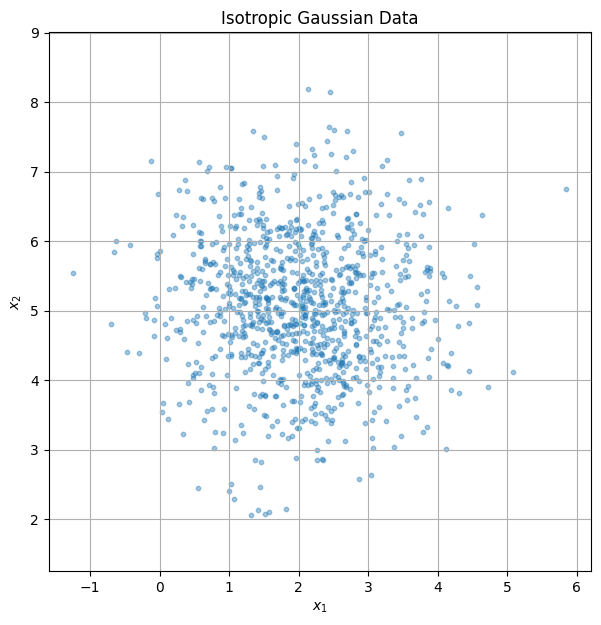

In [5]:
plt.figure(figsize=(7, 7))

plt.scatter(X[:, 0], X[:, 1], s=10, alpha=0.4)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Isotropic Gaussian Data")

plt.axis("equal")
plt.grid()
plt.show()

In [6]:
def plot_constant_density_curves(
    X,
    mean,
    covariance,
    levels=None,
    title="Constant Density Curves"
):

    if levels is None:
        levels = [0.5, 1, 2, 3, 4, 5, 6]

    x_min = X[:, 0].min() - 2
    x_max = X[:, 0].max() + 2
    y_min = X[:, 1].min() - 2
    y_max = X[:, 1].max() + 2

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    points = np.stack(
        [xx - mean[0], yy - mean[1]],
        axis=-1
    )

    inv_cov = np.linalg.inv(covariance)

    # Mahalanobis squared distance
    mahalanobis = np.einsum(
        "...i,ij,...j->...",
        points,
        inv_cov,
        points
    )

    plt.figure(figsize=(8, 8))

    plt.scatter(
        X[:, 0],
        X[:, 1],
        s=8,
        alpha=0.25
    )

    plt.contour(
        xx,
        yy,
        mahalanobis,
        levels=levels
    )

    plt.scatter(
        mean[0],
        mean[1],
        color="black",
        marker="x",
        s=100,
        label="Mean"
    )

    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title(title)

    plt.axis("equal")
    plt.grid()
    plt.legend()

    plt.show()

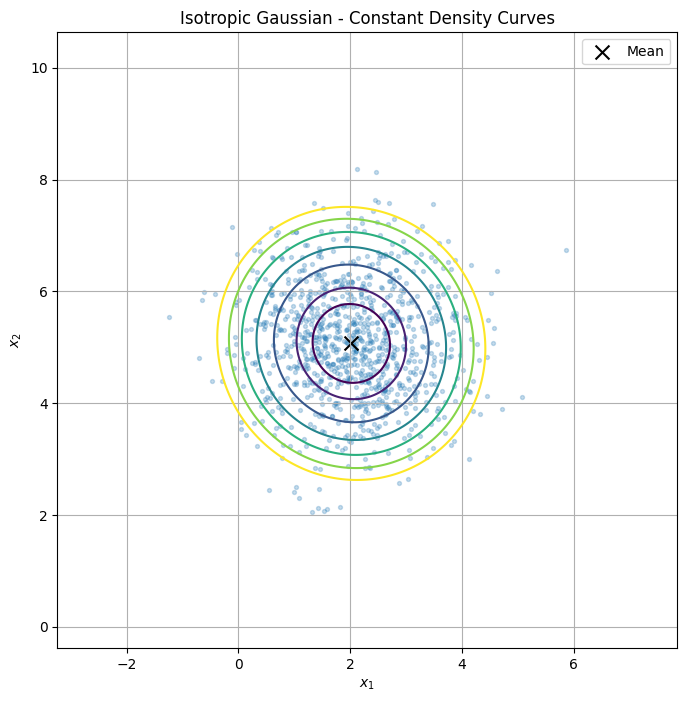

In [7]:
plot_constant_density_curves(
    X,
    mean,
    covariance,
    title="Isotropic Gaussian - Constant Density Curves"
)

In [8]:
def plot_eigenvectors(
    X,
    mean,
    eigenvalues,
    eigenvectors,
    title="Eigenvectors"
):

    plt.figure(figsize=(8, 8))

    plt.scatter(
        X[:, 0],
        X[:, 1],
        s=8,
        alpha=0.25
    )

    # Plot eigenvectors
    for i in range(2):

        vector = eigenvectors[:, i]

        length = np.sqrt(eigenvalues[i])

        plt.arrow(
            mean[0],
            mean[1],
            vector[0] * length * 3,
            vector[1] * length * 3,
            head_width=0.15,
            length_includes_head=True
        )

        plt.text(
            mean[0] + vector[0] * length * 3,
            mean[1] + vector[1] * length * 3,
            f"$\\lambda_{i+1}={eigenvalues[i]:.2f}$"
        )

    plt.scatter(
        mean[0],
        mean[1],
        color="black",
        marker="x",
        s=100
    )

    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title(title)

    plt.axis("equal")
    plt.grid()

    plt.show()

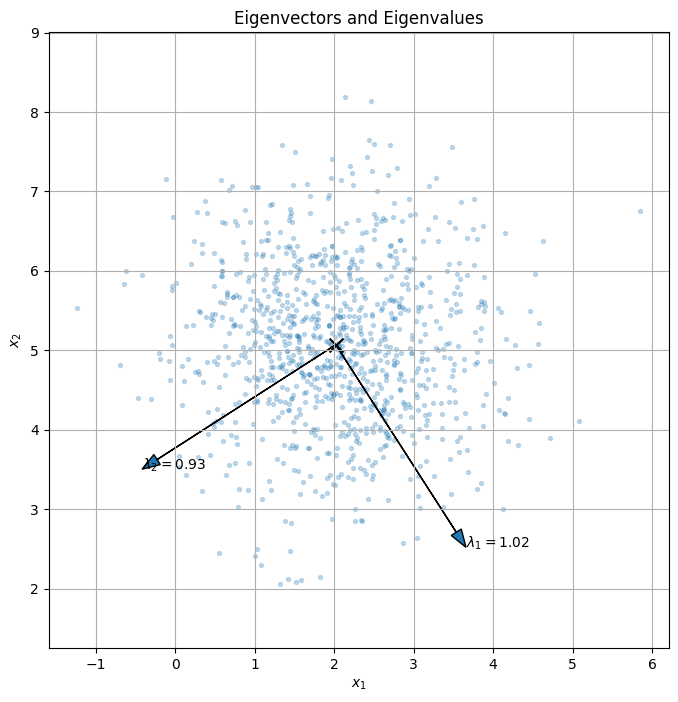

In [9]:
plot_eigenvectors(
    X,
    mean,
    eigenvalues,
    eigenvectors,
    title="Eigenvectors and Eigenvalues"
)

In [10]:
# Diagonal covariance

np.random.seed(42)

N = 1000

mu = np.array([2.0, 5.0])

sigma1 = 1.0
sigma2 = 3.0

X_standard = np.random.randn(N, 2)

# Sigma
Sigma = np.array([
    [sigma1**2, 0],
    [0, sigma2**2]
])

# Sigma^(1/2)
Sigma_sqrt = np.array([
    [sigma1, 0],
    [0, sigma2]
])

# Y = mu + Sigma^(1/2)(X - mu)
Y = mu + (X_standard - mu) @ Sigma_sqrt.T



mean2, covariance2, eigenvalues2, eigenvectors2 = estimate_covariance(Y)

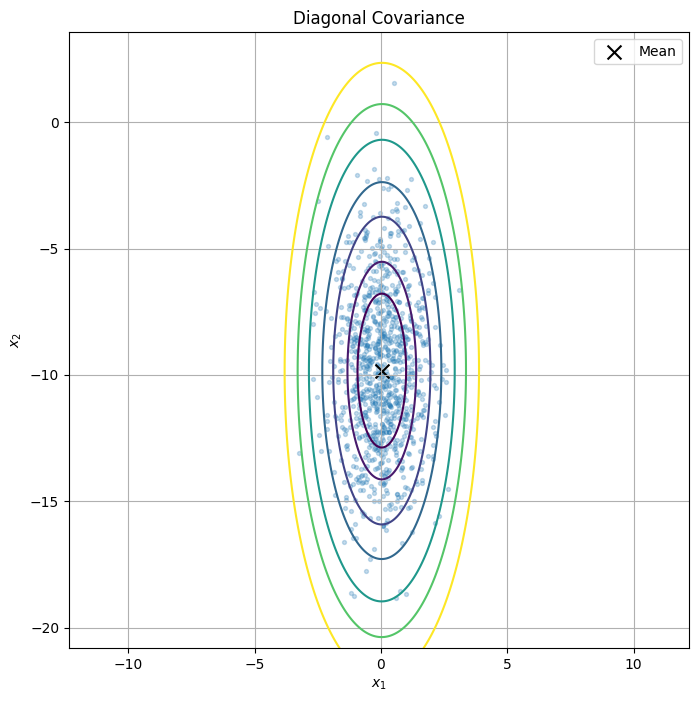

In [11]:
plot_constant_density_curves(
    Y,
    mean2,
    covariance2,
    levels=[1, 2, 4, 6, 9, 12, 16],
    title="Diagonal Covariance"
)

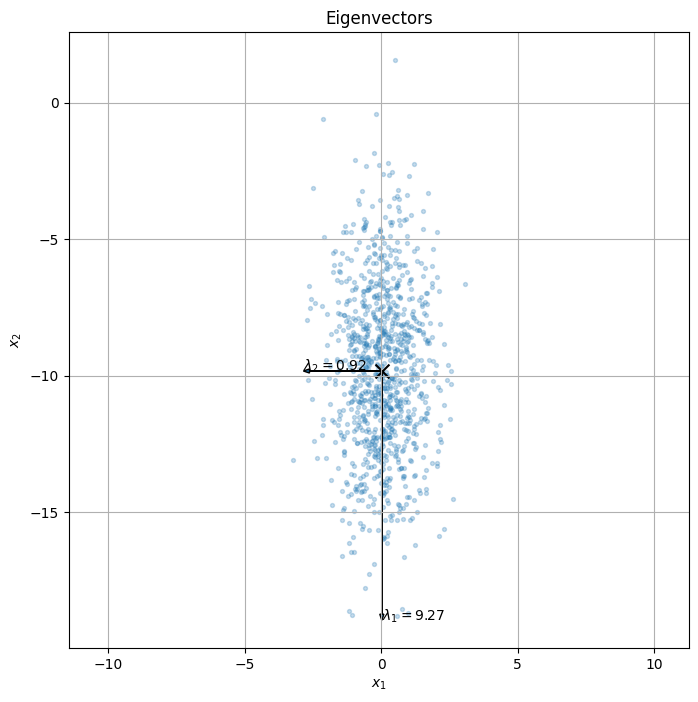

In [12]:
plot_eigenvectors(
    Y,
    mean2,
    eigenvalues2,
    eigenvectors2,
    title="Eigenvectors"
)

In [13]:
# Full covariance

np.random.seed(42)

N = 1000

mu3 = np.array([2.0, 5.0])

Sigma3 = np.array([
    [4.0, 3.0],
    [3.0, 9.0]
])

# Generate multivariate Gaussian data
Y3 = np.random.multivariate_normal(
    mean=mu3,
    cov=Sigma3,
    size=N
)

mean3, covariance3, eigenvalues3, eigenvectors3 = estimate_covariance(Y3)

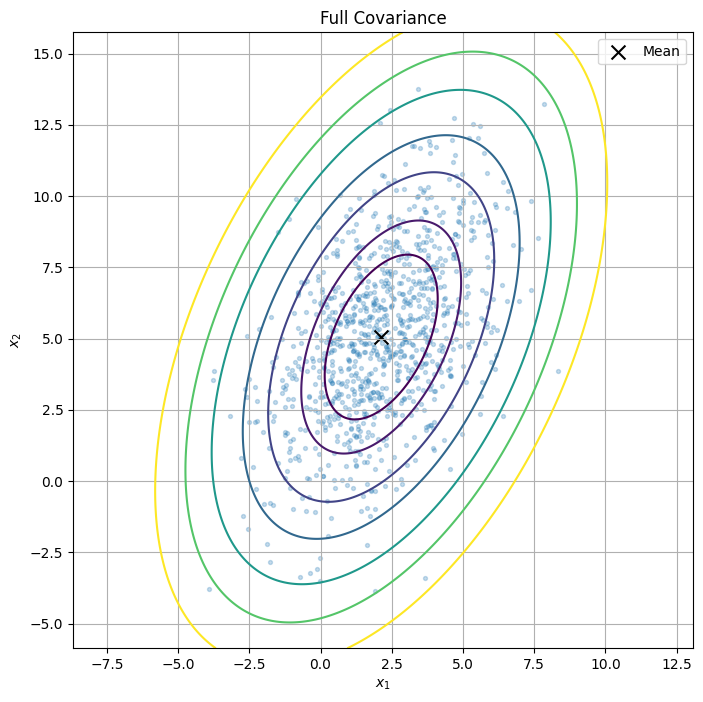

In [14]:
plot_constant_density_curves(
    Y3,
    mean3,
    covariance3,
    levels=[1, 2, 4, 6, 9, 12, 16],
    title="Full Covariance"
)

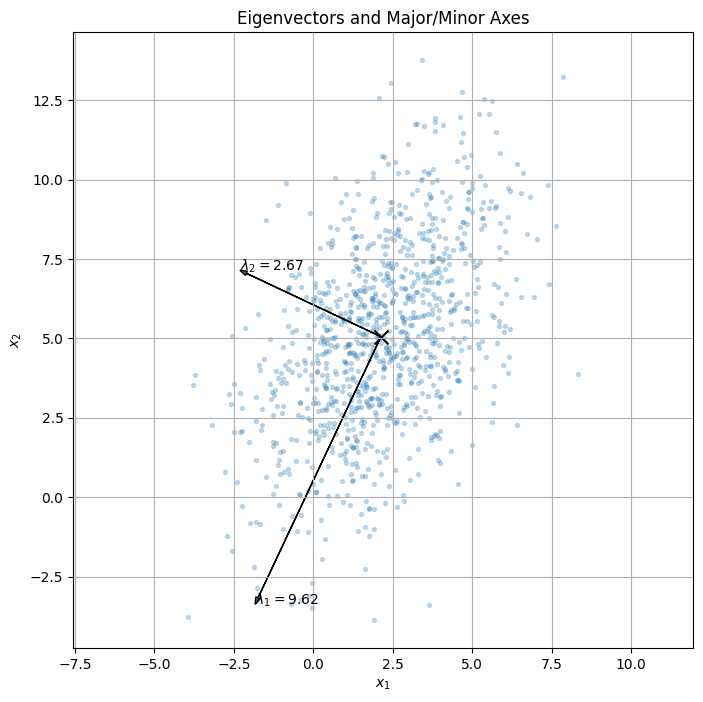

In [15]:
plot_eigenvectors(
    Y3,
    mean3,
    eigenvalues3,
    eigenvectors3,
    title="Eigenvectors and Major/Minor Axes"
)


In [16]:
# Two Gaussian classes

np.random.seed(42)

N = 1000

# Class 1
mu1 = np.array([2.0, 2.0])

Sigma1 = np.array([
    [2.0, 0.0],
    [0.0, 2.0]
])

# Class 2
mu2 = np.array([7.0, 7.0])

Sigma2 = np.array([
    [2.0, 0.0],
    [0.0, 2.0]
])

Y1 = np.random.multivariate_normal(
    mu1,
    Sigma1,
    N
)

Y2 = np.random.multivariate_normal(
    mu2,
    Sigma2,
    N
)

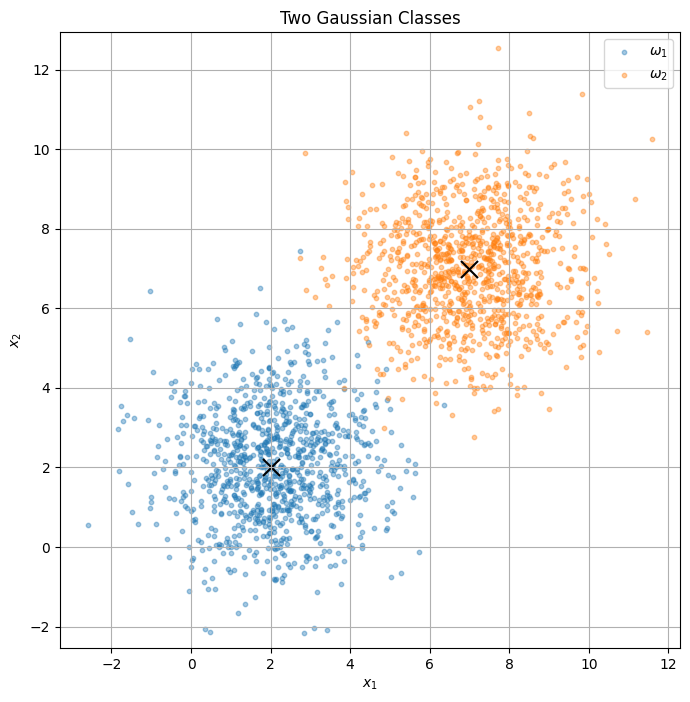

In [17]:
plt.figure(figsize=(8, 8))

plt.scatter(
    Y1[:, 0],
    Y1[:, 1],
    s=10,
    alpha=0.4,
    label="$\\omega_1$"
)

plt.scatter(
    Y2[:, 0],
    Y2[:, 1],
    s=10,
    alpha=0.4,
    label="$\\omega_2$"
)

plt.scatter(
    mu1[0],
    mu1[1],
    marker="x",
    s=150,
    color="black"
)

plt.scatter(
    mu2[0],
    mu2[1],
    marker="x",
    s=150,
    color="black"
)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Two Gaussian Classes")

plt.legend()
plt.axis("equal")
plt.grid()

plt.show()

In [18]:
def gaussian_discriminant(X, mean, covariance):

    inv_cov = np.linalg.inv(covariance)

    sign, logdet = np.linalg.slogdet(covariance)

    diff = X - mean

    mahalanobis = np.einsum(
        "...i,ij,...j->...",
        diff,
        inv_cov,
        diff
    )

    return (
        -0.5 * logdet
        -0.5 * mahalanobis
    )



x_min = min(Y1[:, 0].min(), Y2[:, 0].min()) - 2
x_max = max(Y1[:, 0].max(), Y2[:, 0].max()) + 2

y_min = min(Y1[:, 1].min(), Y2[:, 1].min()) - 2
y_max = max(Y1[:, 1].max(), Y2[:, 1].max()) + 2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.column_stack([
    xx.ravel(),
    yy.ravel()
])



g1 = gaussian_discriminant(
    grid,
    mu1,
    Sigma1
)

g2 = gaussian_discriminant(
    grid,
    mu2,
    Sigma2
)

difference = (g1 - g2).reshape(xx.shape)



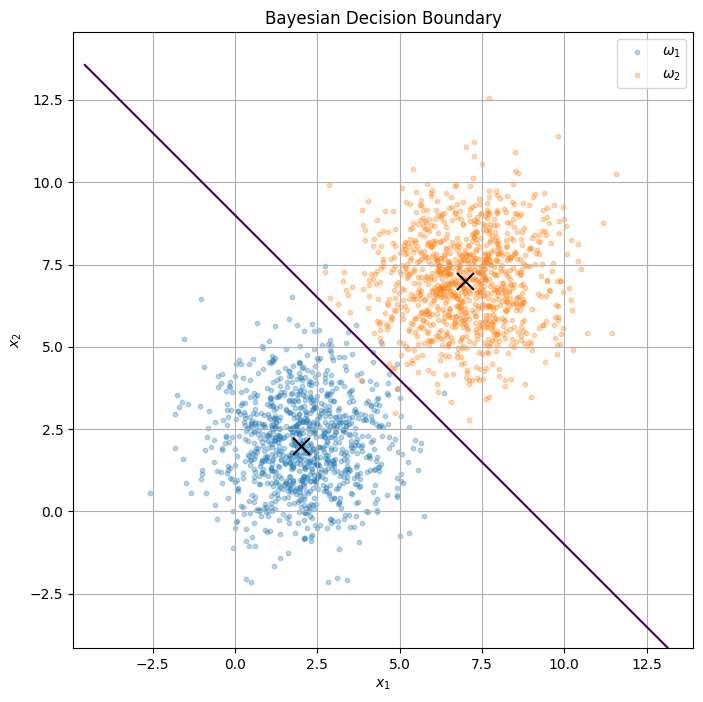

In [19]:
plt.figure(figsize=(8, 8))

plt.scatter(
    Y1[:, 0],
    Y1[:, 1],
    s=10,
    alpha=0.3,
    label="$\\omega_1$"
)

plt.scatter(
    Y2[:, 0],
    Y2[:, 1],
    s=10,
    alpha=0.3,
    label="$\\omega_2$"
)

# Decision boundary
plt.contour(
    xx,
    yy,
    difference,
    levels=[0]
)

plt.scatter(
    mu1[0],
    mu1[1],
    marker="x",
    s=150,
    color="black"
)

plt.scatter(
    mu2[0],
    mu2[1],
    marker="x",
    s=150,
    color="black"
)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Bayesian Decision Boundary")

plt.legend()
plt.axis("equal")
plt.grid()

plt.show()